# Simulation Example: CLUES-ABM under Resource Constraints

This guide demonstrates how to use the `clues_abm` library to simulate and evaluate the dynamic impacts of environmental factors (such as water scarcity) on inter-city economic networks and supply chains.

---

### 1. Module Imports and Engine Instantiation
We import standard data tensor libraries and the vectorized multi-agent class from our core package.

In [2]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt
from clues_abm.WorldOfMatrix_GPU import WorldOfMatrixGPU

# Instantiate the high-performance model engine
model = WorldOfMatrixGPU()
print("CLUES-ABM Matrix Engine successfully instantiated.")

CLUES-ABM Matrix Engine successfully instantiated.


### 2. Temporal Horizon and Discretization Calibration

Before ingesting empirical regional matrices, we parameterize the structural temporal boundaries of the evolutionary ecosystem. 

* **Simulation Horizon (`day_total = 52`)**: Represents a full annual calendar cycle structured across 52 distinct periods (weeks). This temporal mapping matches the accounting frequency of seasonal economic reports and provides the precise window needed to track weekly macroeconomic indicators, business cycles, and policy shock propagation across sub-national trading networks.
* **Temporal Discretization Step (`delta_t = 1/52`)**: Calibrates each fundamental loop iteration to represent exactly one single week, expressed as a fraction of annual systemic input flows. Operating on a weekly time-step optimizes the computational tractability of multi-agent parallel tensors on the GPU while maintaining sufficient granularity to model inventory depletions, contract re-negotiations, and supply chain dislocations.

> ⏳ **Computational Benchmarking & Quick Evaluation Switch**
> * **Expected Runtime**: Executing the full 52-week vectorized socio-ecological simulation takes approximately **30 minutes** (depending on your CPU topology and GPU/CUDA acceleration alignment). 
> * **Quick Evaluation Switch**: If you prefer a rapid functional checkout without waiting, you can manually decrease the temporal boundary variable `day_total` in the code block below (e.g., set `day_total = 8`). This will allow the model to fully bootstrap and execute a shortened lifecycle in just a few seconds.

In [3]:
# Parameterize Temporal Boundaries
# [USER OPTION] Decrease day_total (e.g., 8) for a rapid functional checkout
day_total = 52  # Total simulation period: 52 weeks (1 year)

# Define the temporal discretization step (1 week represented as 1/52 of a year)
delta_t = 1 / 52

print(f"============================================================")
print(f"🚀 CLUES-ABM Execution Pipeline Initiated.")
print(f"⏱️ Target Temporal Horizon: {day_total} Days | delta_t = {delta_t:.6f}")
print(f"💡 Note: Full 52 weeks take ~30 mins. If too slow, reduce 'day_total'.")
print(f"============================================================")

🚀 CLUES-ABM Execution Pipeline Initiated.
⏱️ Target Temporal Horizon: 52 Days | delta_t = 0.019231
💡 Note: Full 52 weeks take ~30 mins. If too slow, reduce 'day_total'.


### 3. Multi-Regional Input-Output (MRIO) Bootstrapping & Agent Initialization
Here, we ingest the empirical inter-regional trade data (`CityLevelMRIO2017-python.mat`) to establish the baseline economic network topology. The tensor structures partition production agents, consumption agents, and transportation agents across highly heterogeneous geographic regions.

In [4]:
print("⏳ Phase 1/3: Ingesting empirical MRIO data structures...")
# Load the empirical data structure
mat = loadmat("data/CityLevelMRIO2017.mat")

# Default targeted inventory periods
# Note: This is (1 + the number of periods the remaining inputs would last after the current production ends). Therefore, it should be >= 1.
ndays_target_default = 1+4.3/7

# Bind structural MRIO network configurations to the agent layers
MRIOdata = {
    "MRIO_Z": mat["MRIO_Z"],
    "MRIO_C": mat["MRIO_C"],
    "MRIO_E": mat["MRIO_Export"],
    "MRIO_IM": mat["MRIO_IM"].flatten(),
    "MRIO_R": int(mat["MRIO_R"].item()),
    "MRIO_S": int(mat["MRIO_S"].item()),
    "MRIO_VA": mat["MRIO_VA"].flatten().reshape(1, -1)
}

print("⏳ Phase 2/3: Loading environmental tensors and aggregation mappings from Excel...")
# Load water intensity and water resource data.
WaterConstraints_Ratio = pd.read_excel("data/WaterVariables.xlsx", sheet_name="WaterConstraints_Ratio", header=None).values
WaterIntensity = pd.read_excel("data/WaterVariables.xlsx", sheet_name="WaterIntensity", header=None).values.reshape(-1)

# Load the conversion matrix from sectors to aggregate sectors.
#  The rows represent products in MRIO table, and the columns are aggregate products 
#  which are used as inputs to the Leontief production function.
#  In the matrix, 1 means the row product belongs to the column aggregate proudct, and 0 otherwise.
#  If it is an identity matrix, the original product classification 
#  will be the same as the aggregate product classification.
#  Experiments show that when inventories are small, aggregation will reduce losses;
#  otherwise using aggregation will slightly increase losses.
S2Sa = pd.read_excel('data/S2Sa.xlsx', sheet_name='S2Sa_Identical', header=None)

print("⏳ Phase 3/3: Mapping structural IO boundaries and bootstrapping ABM agent layers (this may take a moment)...")
# ==== Basic Input-Output variables ====
model.MRIO_R = int(MRIOdata["MRIO_R"]) # Number of regions (cities).
model.MRIO_S = int(MRIOdata["MRIO_S"]) # Number of sectors in each region.
model.MRIO_Z = MRIOdata["MRIO_Z"] # Intermediate flows (in a year) from each city-region to each city-region.
model.MRIO_C = MRIOdata["MRIO_C"] # Consumption. Each column is the consumption of a city from all city-sectors.
model.MRIO_VA = MRIOdata["MRIO_VA"] # Value added of each city-sector.

# Define open-economy variables.
model.OpenEcon = True # China is an open economy.
model.MRIO_E = MRIOdata["MRIO_E"] # Exports.
model.MRIO_IP = MRIOdata["MRIO_IM"][ 0:(model.MRIO_R*model.MRIO_S) ] # Imports by city-sectors.
model.MRIO_IP = model.MRIO_IP.reshape(1,-1)
model.MRIO_IC = MRIOdata["MRIO_IM"][ (model.MRIO_R*model.MRIO_S):(model.MRIO_R*model.MRIO_S+5*model.MRIO_R) ] # Imports by city consumptions.
model.MRIO_IC = model.MRIO_IC @ np.kron(np.eye(model.MRIO_R), np.ones((5, 1))) # To get ChinaEcon.MRIO_R city consumption levels, we need to sum up every 5 columns of ChinaEcon.MRIO_IC, using kron( eye(ChinaEcon.MRIO_R), ones(5,1) ).
model.MRIO_IC = model.MRIO_IC.reshape(1,-1)

# Set MRIO_Dist: default 1
model.MRIO_Dist = 1 * np.ones((model.MRIO_R, model.MRIO_R), dtype=int)
model.MRIO_Dist = model.MRIO_Dist - 1

# Length of each time step, as a fraction of input flows.
model.delta_t = delta_t

# Default targeted inventory days.
model.ndays_Target_Default = ndays_target_default

# Water intensity: placeholder
model.AgentsP_ResourceIntensity = WaterIntensity

# A conversion matrix, each row is a product and each column is an aggregate product. 
# The value is 1 if the column is aggregate product for the row product, otherwise is 0.
model.S2Sa = S2Sa.values # Use the imported conversion matrix.

# Initialize
model.initialize_variables()
model.initialize_production_agents()
model.initialize_consumption_agents()
model.initialize_transportation_agents()

print(f"Socio-ecological network initialized: {model.MRIO_R} Regions, {model.MRIO_S} Sectors aligned.")

⏳ Phase 1/3: Ingesting empirical MRIO data structures...
⏳ Phase 2/3: Loading environmental tensors and aggregation mappings from Excel...
⏳ Phase 3/3: Mapping structural IO boundaries and bootstrapping ABM agent layers (this may take a moment)...
Socio-ecological network initialized: 313 Regions, 42 Sectors aligned.


### 4. Exogenous Regulatory Shocks and Vectorized Simulation Loop
We parameterized three distinct temporal shock windows representing production-capacity reduction constraints (e.g., severe environmental regulation or resource scarcity events). The block propagates supply chain delays across augmented transportation layers over a full 365-day annual horizon.

In [5]:
# Initialize matrix recorders for temporal tracking
S0_Evolution_ValueAdded_ProductionAgents = np.zeros((model.N_P, day_total))
RegionSectors2Regions = np.kron(np.eye(model.MRIO_R), np.ones((model.MRIO_S, 1)))
SS_AgentsP_VA = model.AgentsP_VA
SS_Region_VA = RegionSectors2Regions.T @ SS_AgentsP_VA
S0_ProductInNetwork_Region = np.zeros((model.MRIO_R, model.MRIO_R, day_total))
S0_ProductInNetwork_Region_Change = np.zeros_like(S0_ProductInNetwork_Region)
SS_ProductInNetwork_Region = RegionSectors2Regions.T @ model.AgentsP_ProductInP @ RegionSectors2Regions
S0_Evolution_Scarcity_RegionsProducts = np.zeros((model.MRIO_R, model.Sa, day_total))

print("Starting 52-week vectorized state transition simulation...")

# Core Evolutionary Simulation Loop
for day in range(1, day_total + 1):
    # Print progress milestone logs periodically to avoid standard terminal clutter
    if day % 4 == 0 or day == 1:
        print(f" >>> Simulating Temporal Boundary: Week {day}/{day_total}")
    
    
    # To simulate the impact of resource constraints:
    # We can revise the property obj.WaterConstraints of the WorldOfMatrix_Water object:
    # obj.MRIO_R*1 vector: Water constraints for each MRIO region, FOR THE CURRENT SIMULATION PERIOD.
  
    # Setting up regions where water scarcity occurs:
    # In this example, only one region was set to have water resource restrictions; 
    # Multiple regions can be simultaneously set to generate water resource restrictions, such as Regions_WaterScarcity=[2,3,4,6,7,8];
    # NOTE: Python uses zero-based indexing. 
    # Therefore, an index of 1 specifies the 2nd region.
    Regions_WaterScarcity = 1
    
    if day == 1:  # For example, in the first period, water scarcity occurs:
        WaterConstraints_RatioInput = np.ones(model.MRIO_R)
        WaterConstraints_RatioInput[Regions_WaterScarcity] = WaterConstraints_Ratio[Regions_WaterScarcity]
        model.ResourceConstraints = model.ResourceConstraints * WaterConstraints_RatioInput
    else:  # Very abundant water. PLEASE USE THIS IN EACH SIMULATION PERIOD IF THERE IS NO WATER CONSTRAINT!
        model.ResourceConstraints = np.ones_like(model.ResourceConstraints) * (np.sum(model.AgentsP_SS_Xcap) * 10 + 1e10)

    # --- Augmented Transportation Layers Control (P2P and P2C) ---
    # Tranportation lines:
    # Load, move, and unload goods in the transportation chains.
    # Move one step forward (creating augumented transportation lines), for P2P.
    model.AgentsT_P2P = np.hstack([np.zeros((model.nl_NetPP, 1)), model.AgentsT_P2P])
    # Calculate products loaded to each transportation lines.
    flat_P2P = model.AgentsT_P2P.ravel(order='F').copy()
    flat_P2P[model.AgentsT_P2P_StartLinInd] = model.AgentsP_ProductOutP.ravel(order='F')[model.k_NetPP]
    model.AgentsT_P2P = flat_P2P.reshape(model.AgentsT_P2P.shape, order='F')
    
    # Move one step forward (creating augumented transportation lines), for P2C.
    model.AgentsT_P2C = np.hstack([np.zeros((model.nl_NetPC, 1)), model.AgentsT_P2C])
    # Calculate products loaded to each transportation lines.
    flat_P2C = model.AgentsT_P2C.ravel(order='F').copy()
    flat_P2C[model.AgentsT_P2C_StartLinInd] = model.AgentsP_ProductOutC.ravel(order='F')[model.k_NetPC]  
    model.AgentsT_P2C = flat_P2C.reshape(model.AgentsT_P2C.shape, order='F')
    
    # Transportation line obstruction (optional).
    # HERE WE DO NOTHING SINCE THERE IS NO TRANSPORTATION LINE OBSTRUCTION.

    # Calculate products unloaded to each production agent from transportation lines.
    temp2 = model.AgentsP_ProductInP.T.copy()
    flat_temp = temp2.ravel(order='F').copy()
    flat_temp[model.k_NetPP] = model.AgentsT_P2P[:, -1]
    temp2 = flat_temp.reshape(temp2.shape, order='F')
    model.AgentsP_ProductInP = temp2.T.copy()
    model.AgentsT_P2P = model.AgentsT_P2P[:, :-1]
    
    # Calculate products unloaded to each consumption agent from transportation lines.
    temp2 = model.AgentsC_ProductInP.T.copy()
    flat_temp = temp2.ravel(order='F').copy()
    flat_temp[model.k_NetPC] =  model.AgentsT_P2C[:, -1]
    temp2 = flat_temp.reshape(temp2.shape, order='F')
    model.AgentsC_ProductInP = temp2.T.copy()
    model.AgentsT_P2C = model.AgentsT_P2C[:, :-1]
    del temp2, flat_temp

    # --- Multi-Agent Behavioral Functions ---
    model.agents_communicate()
    model.update_inventories()
    model.update_export_orders()
    model.update_shares()
    model.production_agents_produce()
    model.production_agents_prepare_product_out()
    model.production_agents_prepare_order_out()
    model.production_agents_adapt_to_shocks()
    model.production_agents_adapt_to_shortages()
    model.production_agents_remember()
    model.consumption_agents_consume()
    model.consumption_agents_prepare_order_out()
    model.consumption_agents_remember()

    # --- Capture End-of-Day System States ---
    S0_Evolution_ValueAdded_ProductionAgents[:, day-1] = model.AgentsP_VA.flatten()
    flow = RegionSectors2Regions.T @ model.AgentsP_ProductInP @ RegionSectors2Regions
    S0_ProductInNetwork_Region[:, :, day-1] = flow
    S0_ProductInNetwork_Region_Change[:, :, day-1] = flow - SS_ProductInNetwork_Region
    S0_Evolution_Scarcity_RegionsProducts[:, :, day-1] = model.Scarcity_RegionsProducts

print("Simulation loop execution finalized.")

Starting 52-week vectorized state transition simulation...
 >>> Simulating Temporal Boundary: Week 1/52


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_51548\1190425498.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  WaterConstraints_RatioInput[Regions_WaterScarcity] = WaterConstraints_Ratio[Regions_WaterScarcity]
D:\project\my_jupyter_notebooks\CLUES_AI_Application\clues_abm\WorldOfMatrix_GPU.py:549: RuntimeWarning: divide by zero encountered in divide
  self.AgentsP_Xs = (self.AgentsP_I + (self.AgentsP_a == 0)) / self.AgentsP_a


 >>> Simulating Temporal Boundary: Week 4/52
 >>> Simulating Temporal Boundary: Week 8/52
 >>> Simulating Temporal Boundary: Week 12/52
 >>> Simulating Temporal Boundary: Week 16/52
 >>> Simulating Temporal Boundary: Week 20/52
 >>> Simulating Temporal Boundary: Week 24/52
 >>> Simulating Temporal Boundary: Week 28/52
 >>> Simulating Temporal Boundary: Week 32/52
 >>> Simulating Temporal Boundary: Week 36/52
 >>> Simulating Temporal Boundary: Week 40/52
 >>> Simulating Temporal Boundary: Week 44/52
 >>> Simulating Temporal Boundary: Week 48/52
 >>> Simulating Temporal Boundary: Week 52/52
Simulation loop execution finalized.


### 5. Post-Processing & Visual Analytics
We synthesize the macro-level economic cascading indices by calculating the temporal deviations in regional Value-Added (VA). The pre-rendered line graph mirrors the economic trajectory published in our accompanying manuscript.

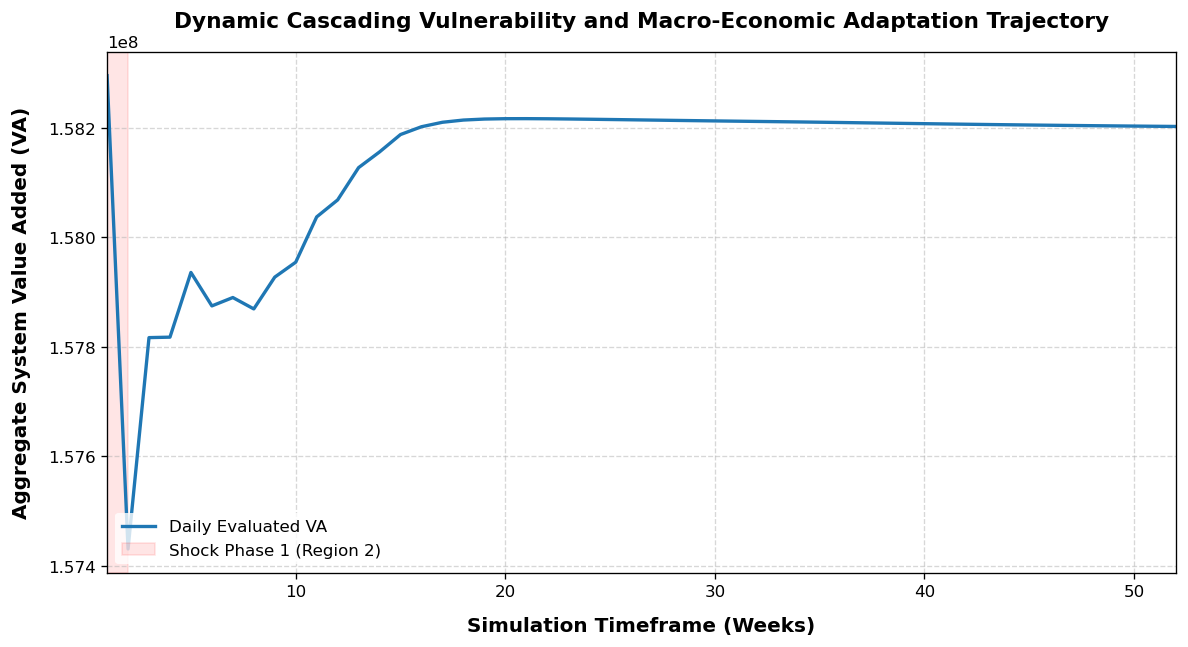

In [6]:
# Compute aggregated macro-level evolution metrics
S0_Evolution_ValueAdded_Region = RegionSectors2Regions.T @ S0_Evolution_ValueAdded_ProductionAgents
daily_total_va = np.sum(S0_Evolution_ValueAdded_ProductionAgents, axis=0)

# ======================= Matplotlib Academic Standard Charting =======================
plt.figure(figsize=(10, 5.5), dpi=120)
plt.plot(range(1, day_total + 1), daily_total_va, label='Daily Evaluated VA', color='#1f77b4', linewidth=2)

# Structural Annotations for Policy Shock Windows
plt.axvspan(1, 2, color='red', alpha=0.1, label='Shock Phase 1 (Region 2)')

# Formatting Aesthetics
plt.xlabel('Simulation Timeframe (Weeks)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Aggregate System Value Added (VA)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Dynamic Cascading Vulnerability and Macro-Economic Adaptation Trajectory', fontsize=13, fontweight='bold', pad=15)
plt.xlim(1, day_total)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none', fontsize=10)
plt.tight_layout()

# Render inline chart directly inside the notebook environment
plt.show()